# **IA para DEVs - 8IADT - Fase 3**

## **Tech Challenge - Assistente Medico Hospitalar**
### **Grupo 49**
### **Integrantes**:
- Rodrigo de Araújo Rosa
- Elias Maximiano da Silva
- Fábia Gomes de Jesus
- Danilo Pereira

### **Desafio**
Após o sucesso na automação de análises de exames e textos clínicos, o hospital quer avançar para
um nível superior de personalização: criar um assistente virtual médico, treinado com os dados
próprios do hospital, capaz de auxiliar nas condutas clínicas, responder dúvidas de médicos e
sugerir procedimentos com base nos protocolos internos.

---

# **Fine-tuning do Assistente Médico Hospitalar** *(GPU L4)*

| Parâmetro | Valor |
|---|---|
| Modelo base | `mistralai/Mistral-7B-Instruct-v0.2` |
| Técnica | QLoRA via PEFT + SFTTrainer (HuggingFace) |
| Ambiente | Google Colab (GPU L4, 22.03 GB VRAM) |
| LoRA rank | **r=64** |
| double_quant | **True** |
| Batch efetivo | **batch=1 + grad_accum=8** |
| Inferência | **Sessão separada** (evita OOM por duplo carregamento do modelo) |
| Tempo de Excecução | 17 Horas |

---

## **Índice**
1. Instalação de Dependências e Configuração Inicial
2. Diagnóstico de Memória (utilitário)
3. Configuração das Variáveis Principais
4. Carregamento e Preparação do Dataset
5. Carregamento do Modelo e Configuração QLoRA
6. Treinamento
7. Inferência e Teste do Modelo *(Sessão separada)*
8. Publicação do Modelo no HuggingFace


## 1. INSTALAÇÃO DE DEPENDÊNCIAS E CONFIGURAÇÃO INICIAL

In [ ]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
%%time
# ==============================================================================
# INSTALAÇÃO DAS BIBLIOTECAS
# Executar apenas na primeira vez ou após reiniciar o ambiente.
# ==============================================================================
!pip install -q -U transformers datasets accelerate peft bitsandbytes trl
!pip install --upgrade -q torchao

import trl, peft, transformers, bitsandbytes
print(f"transformers : {transformers.__version__}")
print(f"trl          : {trl.__version__}")
print(f"peft         : {peft.__version__}")
print(f"bitsandbytes : {bitsandbytes.__version__}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 140.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 96.9 MB/s eta 0:00:00


transformers : 5.8.0
trl          : 1.4.0
peft         : 0.19.1
bitsandbytes : 0.49.2
CPU times: user 20.2 s, sys: 2.66 s, total: 22.8 s
Wall time: 51.2 s


In [ ]:
import os
import gc
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline,
)
from peft import LoraConfig, PeftModel, get_peft_model
from trl import SFTTrainer

# Login no Hugging Face
from huggingface_hub import notebook_login
print("Conectando ao Hugging Face...")
notebook_login()

# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive montado.")

BASE_DIR   = "/content/drive/MyDrive/fase3-data"
PREP_DIR   = os.path.join(BASE_DIR, "preprocessed")
MODELS_DIR = os.path.join(BASE_DIR, "models")
print(f"BASE_DIR  : {BASE_DIR}")
print(f"PREP_DIR  : {PREP_DIR}")
print(f"MODELS_DIR: {MODELS_DIR}")


Conectando ao Hugging Face...
Mounted at /content/drive
Google Drive montado.
BASE_DIR  : /content/drive/MyDrive/fase3-data
PREP_DIR  : /content/drive/MyDrive/fase3-data/preprocessed
MODELS_DIR: /content/drive/MyDrive/fase3-data/models


## 2. DIAGNÓSTICO DE MEMÓRIA (utilitário)

Executar esta célula a qualquer momento para ver o estado atual da VRAM.
É útil para comparar o consumo antes e depois de ajustes.

In [ ]:
def print_gpu_memory(label=""):
    if not torch.cuda.is_available():
        print("GPU não disponível.")
        return
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved  = torch.cuda.memory_reserved()  / 1024**3
    total     = torch.cuda.get_device_properties(0).total_memory / 1024**3
    livre     = total - reserved
    print(f"[{label}]" if label else "[GPU]")
    print(f"  Alocado  : {allocated:.2f} GB")
    print(f"  Reservado: {reserved:.2f} GB")
    print(f"  Total    : {total:.2f} GB")
    print(f"  Livre    : {livre:.2f} GB")

print_gpu_memory("Antes do carregamento do modelo")


[Antes do carregamento do modelo]
  Alocado  : 0.00 GB
  Reservado: 0.00 GB
  Total    : 22.03 GB
  Livre    : 22.03 GB


## 3. CONFIGURAÇÃO DAS VARIÁVEIS PRINCIPAIS

In [ ]:
# ==============================================================================
# CONFIGURAÇÃO DAS VARIÁVEIS PRINCIPAIS
# ==============================================================================

# Modelo base
base_model_id = "mistralai/Mistral-7B-Instruct-v0.2"

# Caminho para o dataset
dataset_path = os.path.join(PREP_DIR, "train_data.json")

# Nome do modelo fine-tuned
new_model_name = "mistral-7b-assistente-hospitalar-v1"

# Diretório de checkpoints no Drive
# local_checkpoint_dir = os.path.join(PREP_DIR, "checkpoints_locais")
# Checkpoint local
local_checkpoint_dir = "./checkpoints_locais"

# Caminho de salvamento final
final_model_save_path = os.path.join(MODELS_DIR, new_model_name)

# Número de amostras (None = dataset completo)
NUM_SAMPLES_FOR_TEST = None

print("Variáveis configuradas:")
print(f"  Modelo base        : {base_model_id}")
print(f"  Dataset            : {dataset_path}")
print(f"  Checkpoint dir     : {local_checkpoint_dir}")
print(f"  Modelo final       : {final_model_save_path}")


Variáveis configuradas:
  Modelo base        : mistralai/Mistral-7B-Instruct-v0.2
  Dataset            : /content/drive/MyDrive/fase3-data/preprocessed/train_data.json
  Checkpoint dir     : ./checkpoints_locais
  Modelo final       : /content/drive/MyDrive/fase3-data/models/mistral-7b-assistente-hospitalar-v1


## 4. CARREGAMENTO E PREPARAÇÃO DO DATASET

In [ ]:
%%time
# ==============================================================================
# CARREGAMENTO DO DATASET
# ==============================================================================
full_dataset = load_dataset("json", data_files=dataset_path, split="train")

dataset = (
    full_dataset.select(range(NUM_SAMPLES_FOR_TEST))
    if NUM_SAMPLES_FOR_TEST is not None
    else full_dataset
)

print(f"Registros carregados: {len(dataset):,}")
print("Exemplo:", dataset[0])


Generating train split: 0 examples [00:00, ? examples/s]

Registros carregados: 211,269
Exemplo: {'instruction': 'As células linfóides inatas do grupo 2 (LCI2) são aumentadas em rinossinusite crônica com pólipos nasais ou eosinofilia?', 'input': '', 'output': 'Como os ILC2s são elevados em pacientes com CRSwNP, eles podem conduzir a formação de pólipo nasal em CRS. Os ILC2s também estão ligados a eosinofilia alta de tecido e sangue e têm um papel potencial na ativação e sobrevivência de eosinófilos durante a resposta imune Th2. A associação de células linfóides inatas em CRS fornece insights sobre sua patogênese.'}
CPU times: user 2.86 s, sys: 633 ms, total: 3.5 s
Wall time: 9.21 s


In [ ]:
%%time
# ==============================================================================
# FUNÇÃO DE FORMATAÇÃO (formato Mistral Instruct)
# ==============================================================================
def format_alpaca_prompt(example):
    if example.get("input"):
        return (
            f"<s>[INST] {example['instruction']}\n{example['input']} "
            f"[/INST] {example['output']} </s>"
        )
    return (
        f"<s>[INST] {example['instruction']} "
        f"[/INST] {example['output']} </s>"
    )

# ==============================================================================
# DIAGNÓSTICO DO COMPRIMENTO DOS PROMPTS
# Usamos uma amostra para estimar o max_length ideal sem tokenizar o dataset
# inteiro (operação cara).
# ==============================================================================
from transformers import AutoTokenizer as _TK
import numpy as np

print("Estimando comprimento dos prompts")
_tok = _TK.from_pretrained(base_model_id)
_sample_size =len(dataset)
_sample = dataset.select(range(_sample_size))
_lengths = [
    len(_tok(format_alpaca_prompt(ex), truncation=False)["input_ids"])
    for ex in _sample
]
_p50  = int(np.percentile(_lengths, 50))
_p95  = int(np.percentile(_lengths, 95))
_p99  = int(np.percentile(_lengths, 99))
_pmax = max(_lengths)
del _tok, _sample

print(f"  Mediana (p50): {_p50} tokens")
print(f"  p95          : {_p95} tokens")
print(f"  p99          : {_p99} tokens")
print(f"  Máximo       : {_pmax} tokens")

# p95 arredondado para múltiplo de 64
MAX_SEQ_LENGTH = 256
print(f"\nMAX_SEQ_LENGTH definido como: {MAX_SEQ_LENGTH}")


Estimando comprimento dos prompts


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

  Mediana (p50): 135 tokens
  p95          : 211 tokens
  p99          : 235 tokens
  Máximo       : 1136 tokens

MAX_SEQ_LENGTH definido como: 256
CPU times: user 1min 7s, sys: 35.9 ms, total: 1min 7s
Wall time: 1min 11s


## 5. CARREGAMENTO DO MODELO E CONFIGURAÇÃO QLORA

| Config | Valor |
|---|---|
| `bnb_4bit_use_double_quant` | `True` |
| `LoRA rank r` | `64` |
| `lora_alpha` | `16` |
| `per_device_train_batch_size` | `1` |
| `gradient_accumulation_steps` | `8` |
| `model_max_length` | `256` |


In [ ]:
%%time
# ==============================================================================
# CONFIGURAÇÃO DE QUANTIZAÇÃO (QLoRA)
# ==============================================================================
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# Carregando o modelo base com quantização
model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map="auto",
)
model.config.use_cache = False
model.config.pretraining_tp = 1

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
tokenizer.model_max_length = MAX_SEQ_LENGTH

print_gpu_memory("Após carregar modelo base (4-bit)")


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

[Após carregar modelo base (4-bit)]
  Alocado  : 3.84 GB
  Reservado: 4.38 GB
  Total    : 22.03 GB
  Livre    : 17.65 GB
CPU times: user 53.5 s, sys: 31.9 s, total: 1min 25s
Wall time: 57 s


In [ ]:
# ==============================================================================
# CONFIGURAÇÃO DO PEFT / LoRA
# ==============================================================================
peft_config = LoraConfig(
    r=64,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    bias="none",
    task_type="CAUSAL_LM",
)

# ==============================================================================
# ARGUMENTOS DE TREINAMENTO
# ==============================================================================
num_epochs = 1
total_steps = (len(dataset) // 1) * num_epochs
warmup_steps_value = int(total_steps * 0.03)

training_arguments = TrainingArguments(
    output_dir=local_checkpoint_dir,
    num_train_epochs=num_epochs,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    optim="paged_adamw_8bit",
    save_steps=500,
    logging_steps=50,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=False,
    bf16=True,
    max_grad_norm=0.3,
    max_steps=-1,
    warmup_steps=warmup_steps_value,
    lr_scheduler_type="constant",
    dataloader_pin_memory=False,
)

print("Configurações definidas.")
print(f"  LoRA r         : {peft_config.r}")
print(f"  lora_alpha     : {peft_config.lora_alpha}")
print(f"  Batch efetivo  : {training_arguments.per_device_train_batch_size * training_arguments.gradient_accumulation_steps}")
print(f"  MAX_SEQ_LENGTH : {tokenizer.model_max_length}")
print(f"  Warmup steps   : {warmup_steps_value}")


Configurações definidas.
  LoRA r         : 64
  lora_alpha     : 16
  Batch efetivo  : 8
  MAX_SEQ_LENGTH : 256
  Warmup steps   : 6338


## 6. TREINAMENTO

In [ ]:
%%time
# ==============================================================================
# INICIALIZAÇÃO DO TRAINER
# ==============================================================================
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    peft_config=peft_config,
    processing_class=tokenizer,
    args=training_arguments,
    formatting_func=format_alpaca_prompt,
)

print_gpu_memory("Antes do treinamento")
print("\nIniciando o fine-tuning (resume_from_checkpoint=True)...")


Applying formatting function to train dataset:   0%|          | 0/211269 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/211269 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/211269 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (258 > 256). Running this sequence through the model will result in indexing errors


[Antes do treinamento]
  Alocado  : 4.15 GB
  Reservado: 4.68 GB
  Total    : 22.03 GB
  Livre    : 17.35 GB

Iniciando o fine-tuning (resume_from_checkpoint=True)...
CPU times: user 1min 53s, sys: 744 ms, total: 1min 54s
Wall time: 1min 47s


In [ ]:
# Inicia (ou retoma) o treinamento
trainer.train(resume_from_checkpoint=True)
print("Fine-tuning concluído!")
print_gpu_memory("Após o treinamento")


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.
[transformers] Warning: The following arguments do not match the ones in the `trainer_state.json` within the checkpoint directory: 
	per_device_train_batch_size: 1 (from args) != 2 (from trainer_state.json)


Step,Training Loss
17550,1.372605
17600,1.368649
17650,1.394183
17700,1.393951
17750,1.352599
17800,1.413458
17850,1.381450
17900,1.350337
17950,1.397816
18000,1.381328


Step,Training Loss
17550,1.372605
17600,1.368649
17650,1.394183
17700,1.393951
17750,1.352599
17800,1.413458
17850,1.381450
17900,1.350337
17950,1.397816
18000,1.381328


Fine-tuning concluído!
[Após o treinamento]
  Alocado  : 4.80 GB
  Reservado: 11.72 GB
  Total    : 22.03 GB
  Livre    : 10.32 GB


Salvando adaptador LoRA em: /content/drive/MyDrive/fase3-data/models/mistral-7b-assistente-hospitalar-v1
Modelo salvo.
Copiando checkpoints para o Drive...
Backup concluído em: /content/drive/MyDrive/fase3-data/preprocessed
Gráfico salvo em: /content/drive/MyDrive/fase3-data/loss_history_mistral-7b-assistente-hospitalar-v1.png


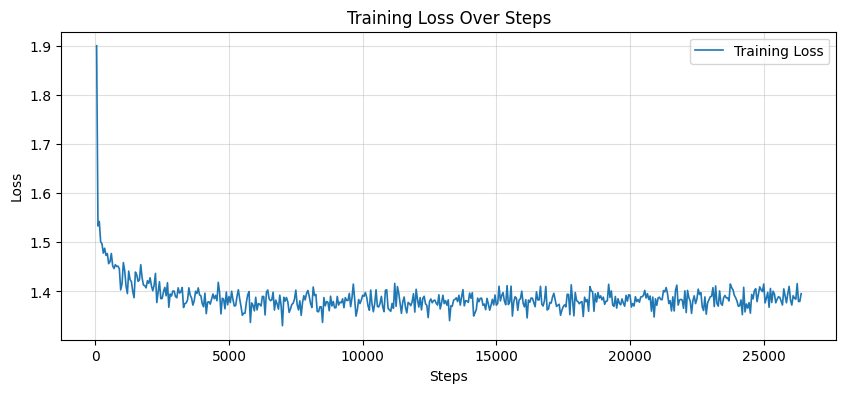


RESUMO FINAL DO FINE-TUNING
  Modelo base    : mistralai/Mistral-7B-Instruct-v0.2
  LoRA rank      : 64
  Épocas         : 1
  Steps totais   : 26409
  Loss final     : 1.3953
  Modelo salvo   : /content/drive/MyDrive/fase3-data/models/mistral-7b-assistente-hospitalar-v1
Fine-tuning concluído com sucesso.


In [ ]:
# ==============================================================================
# SALVAMENTO DO MODELO E ARTEFATOS
# ==============================================================================
import matplotlib.pyplot as plt

print(f"Salvando adaptador LoRA em: {final_model_save_path}")
trainer.save_model(final_model_save_path)
tokenizer.save_pretrained(final_model_save_path)
print("Modelo salvo.")

# Backup dos checkpoints para o Drive
print("Copiando checkpoints para o Drive...")
!cp -r {local_checkpoint_dir} {PREP_DIR}
print(f"Backup concluído em: {PREP_DIR}")

# ==============================================================================
# GRÁFICO DA LOSS
# ==============================================================================
log_history = trainer.state.log_history
steps  = [log["step"] for log in log_history if "loss" in log]
losses = [log["loss"] for log in log_history if "loss" in log]

if steps and losses:
    plt.figure(figsize=(10, 4))
    plt.plot(steps, losses, linewidth=1.2, label="Training Loss")
    plt.title("Training Loss Over Steps")
    plt.xlabel("Steps"); plt.ylabel("Loss")
    plt.grid(True, alpha=0.4); plt.legend()
    loss_plot_path = os.path.join(BASE_DIR, f"loss_history_{new_model_name}.png")
    plt.savefig(loss_plot_path, dpi=120, bbox_inches="tight")
    print(f"Gráfico salvo em: {loss_plot_path}")
    plt.show()

# ==============================================================================
# RESUMO FINAL
# ==============================================================================
final_loss  = losses[-1] if losses else "N/A"
total_steps = trainer.state.global_step
print("\n" + "="*60)
print("RESUMO FINAL DO FINE-TUNING")
print("="*60)
print(f"  Modelo base    : {base_model_id}")
print(f"  LoRA rank      : {peft_config.r}")
print(f"  Épocas         : {training_arguments.num_train_epochs}")
print(f"  Steps totais   : {total_steps}")
print(f"  Loss final     : {final_loss:.4f}" if isinstance(final_loss, float) else f"  Loss final     : {final_loss}")
print(f"  Modelo salvo   : {final_model_save_path}")
print("Fine-tuning concluído com sucesso.")


---

## 7. INFERÊNCIA E TESTE DO MODELO *(executar em sessão separada)*

> ⚠️ **IMPORTANTE**: Execute as células abaixo **somente após reiniciar o
> ambiente do Colab** (`Runtime → Restart runtime`).
>
> **Por quê?** Após o treinamento, o modelo + optimizer + ativações ainda
> ocupam a VRAM. Carregar o modelo base novamente (necessário para o merge
> dos pesos LoRA) causaria um segundo pico de ~14 GB — superando facilmente
> os 22 GB da L4.
>
> Em uma sessão limpa, apenas o modelo de inferência é carregado.

---

### 7.1 – Configuração inicial (nova sessão)


In [ ]:
# ==============================================================================
# EXECUTE ISTO PRIMEIRO em uma nova sessão do Colab
# ==============================================================================
import os, gc, torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline
from peft import PeftModel

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR            = "/content/drive/MyDrive/fase3-data"
MODELS_DIR          = os.path.join(BASE_DIR, "models")
base_model_id       = "mistralai/Mistral-7B-Instruct-v0.2"
new_model_name      = "mistral-7b-assistente-hospitalar-v1"
final_model_save_path = os.path.join(MODELS_DIR, new_model_name)

def print_gpu_memory(label=""):
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved  = torch.cuda.memory_reserved()  / 1024**3
    total     = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"[{label}] Alocado: {allocated:.2f} GB | Reservado: {reserved:.2f} GB | Total: {total:.2f} GB")

print_gpu_memory("Sessão limpa")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Sessão limpa] Alocado: 0.00 GB | Reservado: 0.00 GB | Total: 22.03 GB


### 7.2 – Carregar o modelo + adaptador LoRA

Usamos **4-bit** também na inferência para manter o uso de VRAM dentro dos limites da L4.


In [ ]:
%%time
# ==============================================================================
# CARREGAMENTO DO MODELO BASE (4-bit para inferência)
# Usar 4-bit aqui (em vez de float16) é a diferença entre caber ou não na VRAM.
# A perda de qualidade perceptível na geração é mínima para este caso de uso.
# ==============================================================================
bnb_config_inf = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print(f"Carregando modelo base de: {base_model_id}")
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=bnb_config_inf,
    device_map="auto",
)

tokenizer = AutoTokenizer.from_pretrained(base_model_id)
tokenizer.pad_token = tokenizer.eos_token

print_gpu_memory("Após carregar modelo base (4-bit)")

# ==============================================================================
# APLICAR O ADAPTADOR LoRA
# Não fazemos merge_and_unload aqui: com 4-bit + LoRA aplicado, a inferência
# é mais leve do que carregar o modelo mesclado em float16.
# Se preferir fazer o merge, use float16 no carregamento acima e tenha
# ao menos 18 GB livres antes de executar.
# ==============================================================================
print(f"\nAplicando adaptador LoRA de: {final_model_save_path}")
model_inf = PeftModel.from_pretrained(base_model, final_model_save_path)
model_inf.eval()

print_gpu_memory("Após aplicar LoRA")
print("Modelo pronto para inferência.")


Carregando modelo base de: mistralai/Mistral-7B-Instruct-v0.2


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

[Após carregar modelo base (4-bit)] Alocado: 3.85 GB | Reservado: 4.46 GB | Total: 22.03 GB

Aplicando adaptador LoRA de: /content/drive/MyDrive/fase3-data/models/mistral-7b-assistente-hospitalar-v1
[Após aplicar LoRA] Alocado: 4.47 GB | Reservado: 5.13 GB | Total: 22.03 GB
Modelo pronto para inferência.
CPU times: user 1min 1s, sys: 32.6 s, total: 1min 34s
Wall time: 1min 2s


### 7.3 – Geração de respostas

In [ ]:
%%time
# ==============================================================================
# PIPELINE DE GERAÇÃO
# ==============================================================================
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)
from transformers import GenerationConfig

# Pipeline e função de geração
text_generator = pipeline(
    "text-generation",
    model=model_inf,
    tokenizer=tokenizer,
    device_map="auto",
)

def gerar_resposta(pergunta: str, max_new_tokens: int = 512) -> str:
    prompt = f"<s>[INST] {pergunta} [/INST]"
    result = text_generator(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.6, # T1=0.7; T2=0.4; T3=0.6
        top_p=0.85, # T1=0.9; T2=0.9; T3=0.85
        repetition_penalty=1.1, # T1=1.1; T2=1.15; T3=1.1
        pad_token_id=tokenizer.eos_token_id,
    )
    output = result[0]["generated_text"]
    return output.split("[/INST]")[-1].strip()
# ==============================================================================
# EXEMPLOS DE TESTE
# ==============================================================================
perguntas_teste = [
    "Os baixos níveis séricos de vitamina D estão associados à depressão pós-AVC?",
    "A ceratoprótese de Boston fornece uma ampla profundidade de foco?",
    "Os altos níveis de procalcitonina na fase inicial após o transplante de fígado pediátrico indicam um resultado pós-operatório ruim?",
    "A atividade da autotaxina tem alta precisão para diagnosticar colestase intra-hepática da gravidez?",
    "Os lobar microbleeds estão associados a um declínio no funcionamento executivo em adultos mais velhos?",
]

for pergunta in perguntas_teste:
    print("=" * 60)
    print(f"Pergunta: {pergunta}")
    print("-" * 60)
    resposta = gerar_resposta(pergunta, 1024)
    print(f"Resposta:\n{resposta}")
    print()


Pergunta: Os baixos níveis séricos de vitamina D estão associados à depressão pós-AVC?
------------------------------------------------------------
Resposta:
Nossos resultados mostram que os baixos níveis séricos de 25 (OH) D estão independentemente associados à depressão pós-AVC. Esses achados são consistentes com o conceito de que o 25 (OH) D pode ser um fator protetor contra a depressão pós-AVC.

Pergunta: A ceratoprótese de Boston fornece uma ampla profundidade de foco?
------------------------------------------------------------
Resposta:
O BCP proporciona uma profundidade de foco mais ampla do que o do sistema de lente intraocular.

Pergunta: Os altos níveis de procalcitonina na fase inicial após o transplante de fígado pediátrico indicam um resultado pós-operatório ruim?
------------------------------------------------------------
Resposta:
Altos níveis de PCT no período inicial após o transplante de fígado pediátrico são preditivos de um resultado pós-operatório ruim.

Pergunta

In [ ]:
# ==============================================================================
# BACKUP FINAL DOS CHECKPOINTS PARA O GOOGLE DRIVE
# ==============================================================================

print("Copiando checkpoints locais para o Google Drive...")

# Caminho de destino no Drive
drive_backup_path = PREP_DIR

# cópia recursiva
!cp -r {local_checkpoint_dir} {drive_backup_path}

print(f"Backup concluído! Checkpoints salvos em: {drive_backup_path}")


Copiando checkpoints locais para o Google Drive...
Backup concluído! Checkpoints salvos em: /content/drive/MyDrive/fase3-data/preprocessed


## 8. PUBLICAÇÃO DO MODELO NO HUGGINGFACE


In [ ]:
%%time
from huggingface_hub import HfApi, login

# Login (abre widget para inserir o token)
login()

api = HfApi()

final_model_save_path = "/content/drive/MyDrive/fase3-data/models/mistral-7b-assistente-hospitalar-v1"

# Cria o repositório
api.create_repo(
    repo_id="rodrigoaraujorosa/mistral-7b-assistente-hospitalar-v1",
    repo_type="model",
    private=False,
)

# Faz upload do adaptador LoRA
api.upload_folder(
    folder_path=final_model_save_path,
    repo_id="rodrigoaraujorosa/mistral-7b-assistente-hospitalar-v1",
    repo_type="model",
)

print("Modelo publicado com sucesso!")
print(f"Acesse: https://huggingface.co/rodrigoaraujorosa/mistral-7b-assistente-hospitalar-v1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:10908: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  warnings.warn(f"Warnings while validating metadata in README.md:\n{message}")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...alar-v1/training_args.bin: 100%|##########| 5.71kB / 5.71kB            

  ...adapter_model.safetensors:  10%|9         | 64.0MB /  671MB            

Modelo publicado com sucesso!
Acesse: https://huggingface.co/rodrigoaraujorosa/mistral-7b-assistente-hospitalar-v1
CPU times: user 3.34 s, sys: 1.05 s, total: 4.38 s
Wall time: 38.1 s
